
<h1 id="2.5-%E5%AE%9E%E9%AA%8C%E6%95%B0%E6%8D%AE%E5%A4%84%E7%90%86%E8%BF%87%E7%A8%8B">2.5 实验数据处理过程</h1>


<p>实验数据分析通常沿着<strong>解码 → 刻度 → 事件重建 → 物理分析</strong>展开。原始信号保存一次；在耗时或反复使用的阶段保存中间结果。改变 PID cut 时，不必重新解码。</p><p>每个结果应能追溯到输入 run、事例编号和所用刻度。直方图便于检查，TTree 保留逐事件信息，两者用途不同。</p><h2>第一阶段：从原始读数到可分析的信号</h2><p>DAQ 原始文件按电子学插件协议保存数据块，包含 ADC/TDC 道值、通道地址及 overflow 等状态。读取格式之前，先确认本实验使用的插件协议和 mapping。</p>


<h4 id="%E8%A7%A3%E7%A0%81(decoding-or-mapping)%EF%BC%9A"><font color="Blue">解码(decoding or mapping)</font>：</h4><ul>
<li>解码程序通过读取数据中每个插件的特定标识，按对应协议进行解码。随后，根据实验设定的“探测器信号-插件通道”对应表（Mapping Map），将上述硬件数据转换成每个物理事件中具体探测器的测量值。经过此步骤生成的文件通常称为<strong>原始 ROOT 文件 (Raw ROOT File)</strong>。</li>
</ul>



<h4 id="%E4%BA%8B%E4%BB%B6%E9%87%8D%E6%9E%84(event-building)%EF%BC%9A"><font color="Blue">事件重构(event building)</font>：</h4><ul>
<li>根据探测器信号之间的时间逻辑关系，重新组织和对齐事件结构（具体算法机制见第 5 章）。</li>
</ul>


<h3>步骤一：检查原始道值与量化</h3><p>保留 ADC/TDC 的整数码及无效、overflow 等状态，检查其有效区间。刻度可以直接作用于原始码或 bin 中心。1.3 的 dithering 是基于 bin 内均匀近似的可选处理，不是刻度的必需步骤，也不恢复丢失的精度。</p>

<h3>步骤二：有效信号与可重建信息</h3><p>先按各通道的范围和状态判断有效性，再计算位置、能量等组合量。缺失与真实零值分开保存；无效标记不参与刻度、求和和拟合。</p><p>例如 PPAC 两端时间差可以在 anode 缺失时计算，但本节的 time-sum 检查需要 anode。是否保留这类位置，要用独立 reference tracks 检查 residual 和误判率，不能只因为公式仍能计算就认定结果有效。若采用不同重建方法，在输出中保存方法标记。</p>


<h4 id="%E6%AD%A5%E9%AA%A4%E4%B8%89%EF%BC%9A%E5%85%B3%E9%94%AE%E4%BF%A1%E6%81%AF%E7%9A%84%E7%9B%B4%E6%96%B9%E5%9B%BE%E5%8C%96%E5%AD%98%E5%82%A8-(Histograms)">步骤三：关键信息的直方图化存储 (Histograms)</h4><p>反复查看大型 TTree 的同一分布会重复读取数据。可把常用直方图与树一起保存，或另存为 hist001.root，供日常检查；按具体数据量决定是否缓存。</p>
<ul>
<li><strong>常用信息包括</strong>：ADC/TDC 各通道的原始能谱和时间谱、同类型探测器的 Hit 分布图、探测器间的二维关联谱（如 $\Delta E-E$, $TOF-\Delta E$）等。</li>
</ul>
<p><strong>利用目录结构组织直方图：</strong>
当直方图数量庞大时，可使用 <code>TDirectoryFile</code> 在 ROOT 文件内部创建类似文件系统的目录结构，以便于在 <code>TBrowser</code> 中快速浏览。</p>
<p><em>代码示例：在 ROOT 文件中创建目录并分类存储直方图</em></p>
<p><code>root -l mg18.root</code></p>
<pre><code>root[0] new TBrowser
</code></pre>
<pre><code>- 在左侧栏中双击文件名，在Draw Option栏中填入“colz”等绘图选项。</code></pre>
<p><img alt="" src="fig/root-dir.png"/></p>


In [ ]:
gRandom->SetSeed(2501); // 固定示例的随机数种子
// 1. 创建用于存储直方图的 ROOT 文件
TFile *fout = new TFile("hist_test.root", "RECREATE");

// 2. 在根目录下创建一级目录 dir1 和 dir2
TDirectoryFile *dir1 = new TDirectoryFile("dir1", "ADC Spectra");
TDirectoryFile *dir2 = new TDirectoryFile("dir2", "TDC Spectra");

// 3. 在 dir1 下创建子目录 dir1sub
dir1->cd(); 
TDirectoryFile *dir1sub = new TDirectoryFile("dir1sub", "PPAC Detail");

// 4. 声明并初始化直方图 (注意在 new 之前切换到对应的目录)
TH1I *h0, *h1, *h2, *h1sub;

fout->cd();    // 回到根目录
h0 = new TH1I("h0", "Global Hist", 100, -3, 3);

dir1->cd();    // 进入 dir1
h1 = new TH1I("h1", "ADC Channel 1", 100, -3, 3);

dir1sub->cd(); // 进入子目录
h1sub = new TH1I("h1sub", "PPAC X pos", 100, -3, 3);

dir2->cd();    // 进入 dir2
h2 = new TH1I("h2", "TDC Channel 1", 100, -3, 3);

// 5. 填充数据 (实际分析中通常在 Event Loop 中进行)
h0->FillRandom("gaus", 10000);
h1->FillRandom("gaus", 10000);
h1sub->FillRandom("gaus", 10000);
h2->FillRandom("gaus", 10000);

// 6. 一次性将所有内存中的直方图按目录结构写入文件
fout->Write();
fout->Close();

<p>写入后的目录结构：</p><img alt="1" src="fig/dir.png"/>
<h4 id="Read-hist-from-the-file">Read hist from the file</h4><ul>
<li>root环境直接读取(见上图)</li>
</ul>
<div class="highlight"><pre><span></span><span class="n">root</span><span class="w"> </span><span class="o">-</span><span class="n">l</span><span class="w"> </span><span class="n">hist_test</span><span class="p">.</span><span class="n">root</span>
<span class="o">&gt;</span><span class="k">new</span><span class="w"> </span><span class="n">TBrowser</span>
</pre></div>
<p>在左边树形目录结构中找到文件，鼠标点击进入目录结构，点击相应hist</p>
<ul>
<li>代码读取</li>
</ul>


In [ ]:
TFile *fin=new TFile("hist_test.root");

In [11]:
fin->ls();

TFile**		hist_test.root
 TFile*		hist_test.root
  KEY: TDirectoryFile	dir1;1	ADC Spectra
  KEY: TDirectoryFile	dir2;1	TDC Spectra
  KEY: TH1I	h0;1	Global Hist

In [ ]:
TH1I* h0a=(TH1I*) fin->Get("h0");
TH1I* h1a=(TH1I*) fin->Get("dir1/h1");
TH1I* h2a=(TH1I*) fin->Get("dir2/h2");
TH1I* h1suba=(TH1I*) fin->Get("dir1/dir1sub/h1sub");

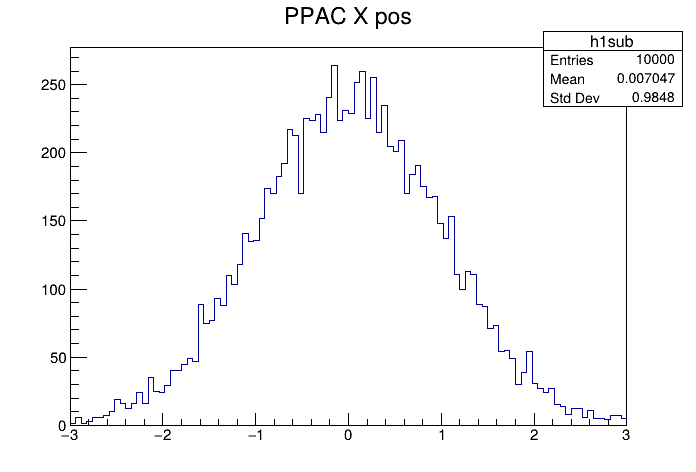

In [13]:
TCanvas *c1 = new TCanvas("c1","Directory example");
h1suba->Draw();
c1->Draw();


<h4 id="%E6%AD%A5%E9%AA%A4%E5%9B%9B%EF%BC%9A%E5%AE%9E%E9%AA%8C%E5%8F%82%E6%95%B0%E4%B8%80%E8%87%B4%E6%80%A7%E6%A3%80%E9%AA%8C-(Drift-Check)">步骤四：实验参数一致性检验 (Drift Check)</h4><p>由于探测器工作条件的变化（温度波动、噪声引入等）以及电子学参数的长期漂移，实验设备的增益或基线可能会随时间发生改变。
<strong>在进入正式物理刻度和设定数据切割条件（Cut）之前，先检查基础参数的时间稳定性，并进行必要的动态修正。</strong></p>
<ul>
<li><strong>文件内变化</strong>：观察参数值随事件编号（Event Number）或绝对时间戳（Timestamp）的变化趋势。</li>
<li><strong>全局变化</strong>：观察参数的统计平均值（如某特征峰的位置、探测器效率、时间分辨）随 Run Number（文件编号）的宏观漂移情况。</li>
</ul>
<p>下图显示某次实验中TDC值、位置探测器分辨、效率等参数随着文件号的变化。
<img alt="3" src="fig/values_run.png"/></p>


<h2>第二阶段：事件重建与物理分析</h2>
<p>用刻度后的信号构建粒子 hit，处理相邻条的 charge sharing、front-back 对应关系和探测器间符合，再计算位置、能量及时间。第三章将逐步处理 DSSD 的这些问题。</p>
<p>物理选择常来自 ΔE–E 或 TOF–ΔE 的 PID、prompt 时间区间以及几何或运动学约束。选择后的数据仍可能含本底，且 cut 会改变效率与接受度。</p>
<p>在确定的反应假设下，用能量和方向计算 Q 值、激发能等物理量。截面还需要束流归一、靶厚、探测效率与接受度。重建和选择参数保存在结果旁，后续改变 cut 时就能知道哪些步骤需要重算。</p>

<h2>批量处理多个 run</h2><p>先确认单个文件能正常处理，再用 Bash 循环调用 2.4 的程序。下面脚本接收起止 run、输入目录、输出目录和程序路径；每个 run 单独留日志，失败时继续处理其他 run，最后返回失败状态。</p><pre><code class="language-cpp">#!/usr/bin/env bash
set -u
if [ "$#" -ne 5 ]; then
    echo "Usage: bash run_batch.sh first last input_dir output_dir program" &gt;&amp;2
    exit 1
fi
first=$1; last=$2; input_dir=$3; output_dir=$4; program=$5
if ! [[ $first =~ ^[0-9]+$ &amp;&amp; $last =~ ^[0-9]+$ ]] || (( first &gt; last )); then
    echo "Invalid run range" &gt;&amp;2
    exit 1
fi
mkdir -p "$output_dir"
failed=0
for ((run=first; run&lt;=last; run++)); do
    printf -v input_file '%s/f8ppac%03d.root' "$input_dir" "$run"
    printf -v output_file '%s/out%03d.root' "$output_dir" "$run"
    if [ ! -f "$input_file" ] || [ -e "$output_file" ]; then
        echo "Skip run $run: missing input or existing output" &gt;&amp;2
        failed=1
        continue
    fi
    if "$program" "$run" "$input_dir" "$output_dir" &gt;"$output_dir/run$run.log" 2&gt;&amp;1; then
        echo "Run $run completed"
    else
        echo "Run $run failed; see $output_dir/run$run.log" &gt;&amp;2
        failed=1
    fi
done
exit "$failed"</code></pre><p>在章目录运行：</p><pre><code class="language-cpp">bash run_batch.sh 1 1 . batch_output code/compile2/tracking</code></pre><p><code>"$var"</code> 保留路径中的空格；<code>&gt;log 2&gt;&amp;1</code> 把正常输出和错误都写入日志。输入文件缺失或程序返回非零状态时，该 run 不被当作成功结果。再次运行前先检查输出目录，避免覆盖此前结果。</p>